<a href="https://colab.research.google.com/github/ayse50/Industrial_Surface_Defect_Classification/blob/main/Surface_Defect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Industrial Surface Defect Classification

##Problem
Manual inspection of metal surfaces in production lines is time-consuming, subjective, and prone to human error. Inaccurate defect detection leads to significant economic losses, material waste, and compromised structural integrity of industrial components.

## Solution
Development of a high-speed Deep Learning pipeline using PyTorch and MobileNetV3-Small. The solution is specifically optimized for Edge-AI deployment by using grayscale processing to minimize computational overhead while maintaining high diagnostic accuracy for real-time quality control.

## Dataset
* Content: Grayscale images of steel strips (NEU Surface Defect Database)
* Classes: 6 (Crazing, Inclusion, Patches, Pitted Surface, Rolled-in Scale, and Scratches)
* Scale: 1,800 images total, split into Training, Validation, and Test sets

## 1. Visualisation, Preprocessing and Transformation

### 1.1 Downloading Dataset from Kaggle



In [3]:
!pip install opendatasets --upgrade --quiet

In [4]:
import opendatasets as od
dataset_url = 'https://www.kaggle.com/datasets/kaustubhdikshit/neu-surface-defect-database'
od.download(dataset_url)


Dataset URL: https://www.kaggle.com/datasets/kaustubhdikshit/neu-surface-defect-database


100%|██████████| 26.4M/26.4M [00:00<00:00, 113MB/s]


### 1.2 Raw Data Inspection

In [5]:
import os
from PIL import Image
import numpy as np

# Defining the path to one of the training folders
sample_class_path = '/content/neu-surface-defect-database/NEU-DET/train/images/inclusion'
all_files = os.listdir(sample_class_path)
sample_file = [f for f in all_files if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp' ))][0]
full_path = os.path.join(sample_class_path, sample_file)

# Check original dimension and color mode using PIL
with Image.open(full_path) as img:
  width, height =img.size
  mode = img.mode #'L'= Grayscale, 'RGB'=color
  channels = len(img.getbands())

  print(f'----Original Data Check----')
  print(f'Sample Image: {sample_file}')
  print(f'Resolution: {width}x{height}')
  print(f'Color Mode: {mode} ({channels} channel(s))')

  # Check raw pixel values
  img_array = np.array(img)
  print(f'Min Pixel Value: {img_array.min()}')
  print(f'Max Pixel Value: {img_array.max()}')




----Original Data Check----
Sample Image: inclusion_128.jpg
Resolution: 200x200
Color Mode: RGB (3 channel(s))
Min Pixel Value: 54
Max Pixel Value: 113


### 1.3 Define paths to the existing datasets

In [6]:
import os
import torch
import torchvision
from torchvision import datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from torchvision.transforms import ToTensor

# Base directory for the NEU_Surface_Defect dataset
base_dir = '/content/neu-surface-defect-database/NEU-DET'
train_dir = os.path.join(base_dir, 'train/images')
val_dir = os.path.join(base_dir, 'validation/images')


RuntimeError: Only a single TORCH_LIBRARY can be used to register the namespace prims; please put all of your definitions in a single TORCH_LIBRARY block.  If you were trying to specify implementations, consider using TORCH_LIBRARY_IMPL (which can be duplicated).  If you really intended to define operators for a single namespace in a distributed way, you can use TORCH_LIBRARY_FRAGMENT to explicitly indicate this.  Previous registration of TORCH_LIBRARY was registered at /usr/local/lib/python3.12/dist-packages/torch/_prims/__init__.py:37; latest registration was registered at /usr/local/lib/python3.12/dist-packages/torch/_prims/__init__.py:37

### 1.4 Image Transormation

In [25]:
torch.manual_seed(42)
# Augmentation for Training
train_transform = transforms.Compose([transforms.Resize((224,224)),
                                      transforms.RandomHorizontalFlip(),
                                      transforms.RandomRotation(15),
                                      transforms.RandomVerticalFlip(),
                                      transforms.Grayscale(num_output_channels=1),
                                      transforms.ColorJitter(brightness=0.3, contrast=0.3),
                                      transforms.ToTensor(),
                                      transforms.Normalize(mean=[0.5],std=[0.5])])


# Transformation for Validation
val_transform = transforms.Compose([transforms.Resize((224,224)),
                                     transforms.Grayscale(num_output_channels=1),
                                     transforms.ToTensor(),
                                     transforms.Normalize(mean=[0.5],std=[0.5])])




### 1.4 Create Validation and Test Split

In [30]:
from logging import root
# Load original folders
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
temp_val_dataset = datasets.ImageFolder(root=val_dir, transform=val_transform)

# Split Validation folder: 50% Validation, 50% Testing
val_size = len(temp_val_dataset) // 2
test_size = len(temp_val_dataset) - val_size
val_dataset, test_dataset = random_split(temp_val_dataset, [val_size, test_size])



### 1.5 Create Dataloaders

In [31]:
import os
from torchvision import datasets
from torch.utils.data import DataLoader

BATCH_SIZE = 32

#Training
train_loader = DataLoader(train_dataset,
                          batch_size=BATCH_SIZE,
                          shuffle=True)

#Validation
val_loader = DataLoader(val_dataset,
                        batch_size=BATCH_SIZE,
                        shuffle=False)

#Test
test_loader = DataLoader(test_dataset,
                         batch_size=BATCH_SIZE,
                         shuffle=False)

print(f"--- Dataset Split Complete ---")
print(f"Training images: {len(train_dataset)}")
print(f"Validation images: {len(val_dataset)}")
print(f"Testing images: {len(test_dataset)}")
print(f"Detected classes: {train_dataset.classes}")


--- Dataset Split Complete ---
Training images: 1440
Validation images: 180
Testing images: 180
Detected classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


### 1.6 Verify Data Loading

In [32]:
images, labels = next(iter(train_loader))
class_names = train_dataset.classes
images.shape, labels.shape

(torch.Size([32, 1, 224, 224]), torch.Size([32]))

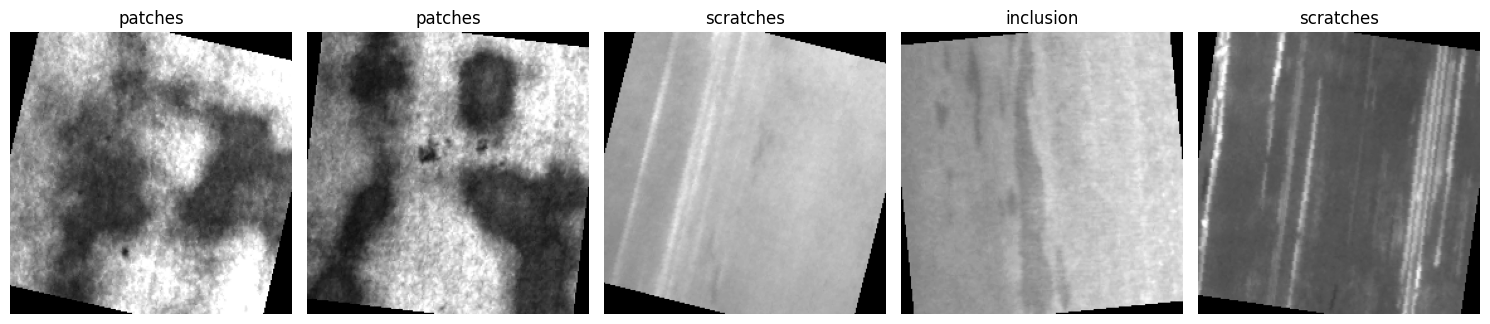

In [34]:
torch.manual_seed(42)
def visualize_batch(images, labels, class_names, num_images=5):
    # Denormalize images for visualization: (img * std) + mean
    # Since mean=[0.5] and std=[0.5] for grayscale, it's (img * 0.5) + 0.5
    images = images * 0.5 + 0.5

    plt.figure(figsize=(15, 5))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        # Remove the channel dimension for grayscale image plotting
        plt.imshow(images[i].squeeze().cpu().numpy(), cmap='gray')
        plt.title(class_names[labels[i]])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Visualize a few images from the batch
visualize_batch(images, labels, class_names, num_images=5)

In [40]:
#Function to count the number of images per class for a dataset
from collections import Counter

def get_class_counts(dataset):
    # Get the class indices for all images in the dataset
    labels = [label for _, label in dataset]

    # Count the occurrences of each class index
    class_counts = Counter(labels)

    return class_counts

def print_class_distribution(dataset, dataset_name, class_names):
    class_counts = get_class_counts(dataset)
    print(f"--- Class Distribution in {dataset_name} ---")
    for class_idx, count in class_counts.items():
        class_name = class_names[class_idx]
        print(f"  {class_name}: {count} images")
    print("\n")


print_class_distribution(train_dataset, "Training Set", train_dataset.classes)
print_class_distribution(val_dataset, "Validation Set", train_dataset.classes)
print_class_distribution(test_dataset, "Test Set", train_dataset.classes)

--- Class Distribution in Training Set ---
  crazing: 240 images
  inclusion: 240 images
  patches: 240 images
  pitted_surface: 240 images
  rolled-in_scale: 240 images
  scratches: 240 images


--- Class Distribution in Validation Set ---
  scratches: 34 images
  inclusion: 31 images
  patches: 29 images
  pitted_surface: 26 images
  rolled-in_scale: 31 images
  crazing: 29 images


--- Class Distribution in Test Set ---
  patches: 31 images
  scratches: 26 images
  inclusion: 29 images
  rolled-in_scale: 29 images
  crazing: 31 images
  pitted_surface: 34 images




### 1.7 Visualize Data Distribution

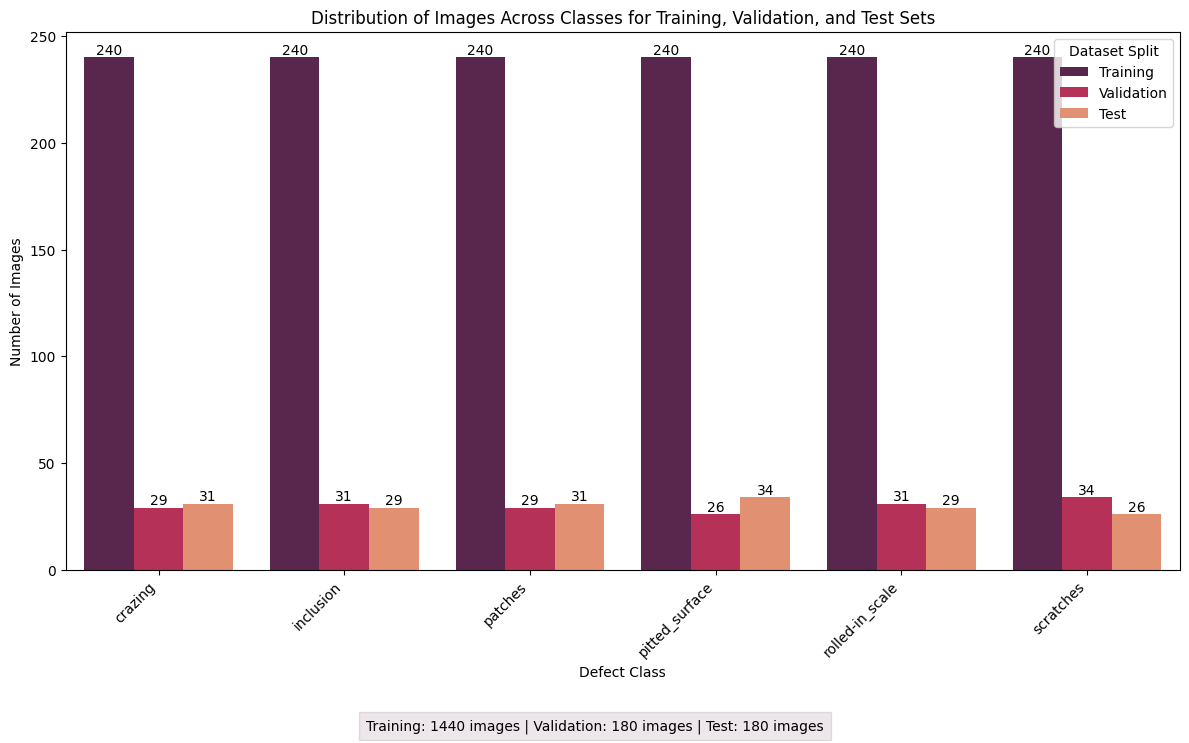

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get class counts for each dataset
train_class_counts = get_class_counts(train_dataset)
val_class_counts = get_class_counts(temp_val_dataset) # Use temp_val_dataset to get original validation distribution before split
test_class_counts = get_class_counts(temp_val_dataset) # Use temp_val_dataset for test as well, it represents the base validation folder

# Create a DataFrame for plotting
data = {
    'Dataset': [],
    'Class': [],
    'Count': []
}

for class_idx, count in train_class_counts.items():
    data['Dataset'].append('Training')
    data['Class'].append(train_dataset.classes[class_idx])
    data['Count'].append(count)

for class_idx, count in val_class_counts.items():
    pass

# Manually create data for plotting based on the print_class_distribution output
data = {
    'Dataset': [
        'Training', 'Training', 'Training', 'Training', 'Training', 'Training',
        'Validation', 'Validation', 'Validation', 'Validation', 'Validation', 'Validation',
        'Test', 'Test', 'Test', 'Test', 'Test', 'Test'
    ],
    'Class': [
        'crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches',
        'scratches', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'crazing',
        'patches', 'scratches', 'inclusion', 'rolled-in_scale', 'crazing', 'pitted_surface'
    ],
    'Count': [
        240, 240, 240, 240, 240, 240,
        34, 31, 29, 26, 31, 29,
        31, 26, 29, 29, 31, 34
    ]
}

df_plot = pd.DataFrame(data)

# Create the bar plot
plt.figure(figsize=(12, 7))
ax = sns.barplot(x='Class', y='Count', hue='Dataset', data=df_plot, palette='rocket')
plt.title('Distribution of Images Across Classes for Training, Validation, and Test Sets')
plt.xlabel('Defect Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Dataset Split')
for container in ax.containers:
  ax.bar_label(container)

plt.figtext(0.5, -0.05,
                "Training: 1440 images | Validation: 180 images | Test: 180 images",
                ha="center", fontsize=10, bbox={"facecolor":"#580F41", "alpha":0.1, "pad":5})
plt.tight_layout()
plt.savefig('class_distribution.png')
plt.show()

## 2. Model, Loss and Optimizer

### 2.1 Setup Model

In [2]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# Setup device agnostic code
device = 'cuda' if torch.cuda.is_available() else'cpu'

# Load MobileNetV3 small. Optimized for Edge devices and real_time inference
model = models.mobilenet_v3_small(weights= 'IMAGENET1K_V1')

# Modify Input-Layer: 3 color Channel (RGB) --> 1 Color Channel(Grayscale)
old_conv = model.features[0][0]
model.features[0][0] = nn.Conv2d(
    in_channels=1,
    out_channels=old_conv.out_channels,
    kernel_size=old_conv.kernel_size,
    stride=old_conv.stride,
    padding=old_conv.padding,
    bias=False
)

# Modify Outpu-Layer: 1000 Classes --> 6 Classes
model.classifier[3] = nn.Linear(model.classifier[3].in_features, 6)
model = model.to(device)

print(f'Model successfully initialized on: {device}')
print(f'Output classes set to: {model.classifier[3].out_features}')





KeyboardInterrupt: 

### 2.2 Define Loss Function

In [1]:
loss_fn = nn.CrossEntropyLoss()

NameError: name 'nn' is not defined

### 2.3 Define Optimizer

In [72]:
for param in model.parameters():
  param.requires_grad = True
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.003)

### 2.4 Download Helper functions (accuracy function)

In [73]:
import requests
from pathlib import Path

# download Helper functions from Learn PyTorch repo
if Path('helper:functions.py').is_file():
  print('helper_functions.py already exists, skipping download...')
else:
  print('Downloading helper_functions.py')
  request = requests.get('https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py')
  with open('helper_functions.py','wb') as f: # wb= write binary, f=file
    f.write(request.content)

# accuracy metric
from helper_functions import accuracy_fn

### 2.5 Define function for timing the experiment

In [74]:
# function for timing the experiment
from timeit import default_timer as timer
def train_time(start: float, end:float, device: torch.device = None):
  total_time = end -start
  print(f'Train time on {device}: {total_time:.3f} seconds')
  return total_time


## 3. Creating Training & Validation loop


In [75]:
from tqdm.auto import tqdm
torch.manual_seed(42)

from timeit import default_timer as timer
train_time_start = timer()
epochs = 10

for epoch in tqdm(range(epochs)):
  print(f'Epoch: {epoch}\n-------')
  #Training loop
  train_loss, train_acc = 0, 0
  model.to(device)
  for batch, (X, y) in enumerate(train_loader):
    X, y = X.to(device), y.to(device)
    y_pred = model(X)
    loss = loss_fn(y_pred, y)
    train_loss += loss
    train_acc +=accuracy_fn(y_true =y,
                            y_pred = y_pred.argmax(dim=1))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  train_loss /= len(train_loader)
  train_acc /= len(train_loader)
  print(f'\nTrain loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%')


  #Validation loop
  val_loss, val_acc = 0, 0
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for X, y in val_loader:
      X, y = X.to(device), y.to(device)
      val_pred =model(X)
      val_loss += loss_fn(val_pred, y)
      val_acc += accuracy_fn(y_true =y,
                             y_pred = val_pred.argmax(dim=1))

    val_loss /= len(val_loader)
    val_acc /= len(val_loader)
    print(f'\nValidation loss: {val_loss:.5f} | Validation accuracy: {val_acc:.2f}%')

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0
-------

Train loss: 0.34332 | Train accuracy: 87.85%

Validation loss: 2.13344 | Validation accuracy: 14.79%
Epoch: 1
-------

Train loss: 1.88075 | Train accuracy: 18.12%

Validation loss: 1.80949 | Validation accuracy: 17.40%
Epoch: 2
-------

Train loss: 1.96465 | Train accuracy: 16.04%

Validation loss: 1.80160 | Validation accuracy: 17.40%
Epoch: 3
-------

Train loss: 1.79625 | Train accuracy: 17.01%

Validation loss: 1.79878 | Validation accuracy: 14.79%
Epoch: 4
-------

Train loss: 1.79802 | Train accuracy: 14.93%

Validation loss: 1.79206 | Validation accuracy: 16.67%
Epoch: 5
-------

Train loss: 1.79422 | Train accuracy: 16.39%

Validation loss: 1.79316 | Validation accuracy: 16.67%
Epoch: 6
-------

Train loss: 1.79511 | Train accuracy: 16.60%

Validation loss: 1.79223 | Validation accuracy: 17.08%
Epoch: 7
-------

Train loss: 1.79610 | Train accuracy: 14.79%

Validation loss: 1.79242 | Validation accuracy: 17.08%
Epoch: 8
-------

Train loss: 1.79287 | Train ac

## 4. Prediction & Evaluation

### 4.1 Prediction

In [ ]:
# Final Test
model.eval()
test_acc = 0
test_loss = 0

print("Running final evaluation on unseen test data...")
with torch.inference_mode():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        test_pred = model(X)

        test_loss += loss_fn(test_pred, y).item()
        test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))

    test_loss /= len(test_loader)
    test_acc /= len(test_loader)
    print(f"\nFinal Results:")
    print(f'\nTest loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%')



### 4.2 Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import torch

y_preds = []
y_true = []

# Ensure model is in evaluation mode and on the correct device
model.eval()
model.to(device)

print("Generating Confusion Matrix...")

with torch.inference_mode():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        test_pred = model(X)
        y_preds.extend(test_pred.argmax(dim=1).cpu().numpy())
        y_true.extend(y.cpu().numpy())

cm = confusion_matrix(y_true, y_preds)
class_names = train_dataset.classes

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap='PuRd', ax=ax)
ax.set_title('Confusion Matrix: Where does the model fail?', fontsize=16)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')

plt.tight_layout()
plt.show()

### 4.3 Evaluation Summary Table

In [ ]:
import pandas as pd

metrics_data = {
    'Metric': ['Train Loss', 'Train Accuracy', 'Validation Loss', 'Validation Accuracy', 'Test Loss', 'Test Accuracy'],
    'Value': [
        f'{train_loss:.4f}',
        f'{train_acc:.2f}%',
        f'{val_loss:.4f}',
        f'{val_acc:.2f}%',
        f'{test_loss:.4f}',
        f'{test_acc:.2f}%'
    ]
}

df_metrics = pd.DataFrame(metrics_data)
display(df_metrics)